In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

In [2]:
engData = pd.read_csv('./data/eng_data.csv')

In [3]:
print(engData.head().to_markdown())

|    | Timestamp           |   TransactionID |   AccountID |          Amount | Merchant   | TransactionType   | Location      |   Year |   Quarter |   Month | Day_Of_Week   |   Day_Of_Month |   Day_Of_Year |   Hour |   Minute |
|---:|:--------------------|----------------:|------------:|----------------:|:-----------|:------------------|:--------------|-------:|----------:|--------:|:--------------|---------------:|--------------:|-------:|---------:|
|  0 | 2023-01-01 06:03:00 |          308153 |           6 | 100000          | J          | Withdrawal        | New York      |   2023 |         1 |       1 | Sunday        |              1 |             1 |      6 |        3 |
|  1 | 2023-01-01 06:03:00 |          269299 |           3 | 105628          | J          | Transfer          | New York      |   2023 |         1 |       1 | Sunday        |              1 |             1 |      6 |        3 |
|  2 | 2023-01-01 06:16:00 |          331884 |          13 |      1.0421e+06 | B        

In [4]:

print(engData[engData['TransactionType'] == 'Transfer'].head().to_markdown())
transfer_Merchants = engData[engData['TransactionType'] == 'Transfer']['Merchant'].unique()
transfer_Accounts = engData[engData['TransactionType'] == 'Transfer']['AccountID'].unique()
transfer_Merchants.sort()
transfer_Accounts.sort()
print(transfer_Merchants)
print(transfer_Accounts)

print(engData[engData['TransactionType'] == 'Withdrawal'].head().to_markdown())
withdrawal_Merchants = engData[engData['TransactionType'] == 'Withdrawal']['Merchant'].unique()
withdrawal_Accounts = engData[engData['TransactionType'] == 'Withdrawal']['AccountID'].unique()
withdrawal_Merchants.sort()
withdrawal_Accounts.sort()
print(withdrawal_Merchants)
print(withdrawal_Accounts)


print(engData[engData['TransactionType'] == 'Purchase'].head().to_markdown())
purchase_Merchants = engData[engData['TransactionType'] == 'Purchase']['Merchant'].unique()
purchase_Accounts = engData[engData['TransactionType'] == 'Purchase']['AccountID'].unique()
purchase_Merchants.sort()
purchase_Accounts.sort()
print(purchase_Merchants)
print(purchase_Accounts)


# All Merchants participate in all Transaction Types

|    | Timestamp           |   TransactionID |   AccountID |   Amount | Merchant   | TransactionType   | Location    |   Year |   Quarter |   Month | Day_Of_Week   |   Day_Of_Month |   Day_Of_Year |   Hour |   Minute |
|---:|:--------------------|----------------:|------------:|---------:|:-----------|:------------------|:------------|-------:|----------:|--------:|:--------------|---------------:|--------------:|-------:|---------:|
|  1 | 2023-01-01 06:03:00 |          269299 |           3 |   105628 | J          | Transfer          | New York    |   2023 |         1 |       1 | Sunday        |              1 |             1 |      6 |        3 |
|  4 | 2023-01-01 06:55:00 |           38295 |           2 |   334514 | J          | Transfer          | New York    |   2023 |         1 |       1 | Sunday        |              1 |             1 |      6 |       55 |
|  5 | 2023-01-01 07:03:00 |           17785 |           8 |   355427 | J          | Transfer          | Los Angeles |   202

In [5]:
# List Unique Categorical Values
print('Unique Values:')
for col in ['AccountID', 'Merchant', 'TransactionType', 'Location']:
    print(col,':',len(engData[col].unique()),'->',engData[col].unique())

Unique Values:
AccountID : 15 -> [ 6  3 13 14  2  8 10  9  5  7 12 11  4  1 15]
Merchant : 10 -> ['J' 'B' 'F' 'D' 'H' 'C' 'G' 'E' 'I' 'A']
TransactionType : 3 -> ['Withdrawal' 'Transfer' 'Purchase']
Location : 5 -> ['New York' 'San Francisco' 'Los Angeles' 'London' 'Tokyo']


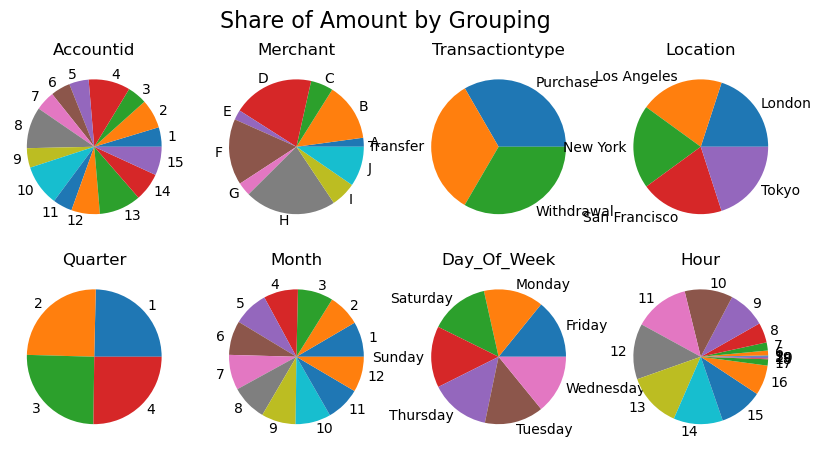

In [6]:
# Check for Amount Sum across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = engData.groupby(col)['Amount'].sum()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Share of Amount by Grouping', fontsize=16)
plt.show()

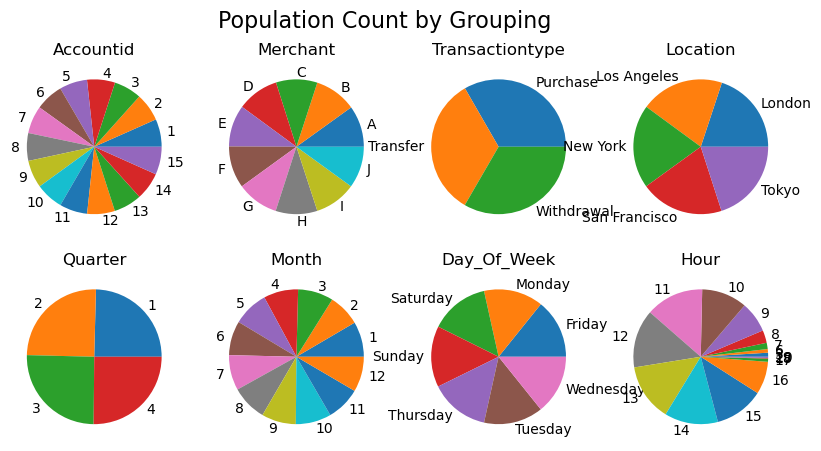

In [7]:
# Check for Population Balance across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = engData.groupby(col)['Amount'].count()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Population Count by Grouping', fontsize=16)
plt.show()

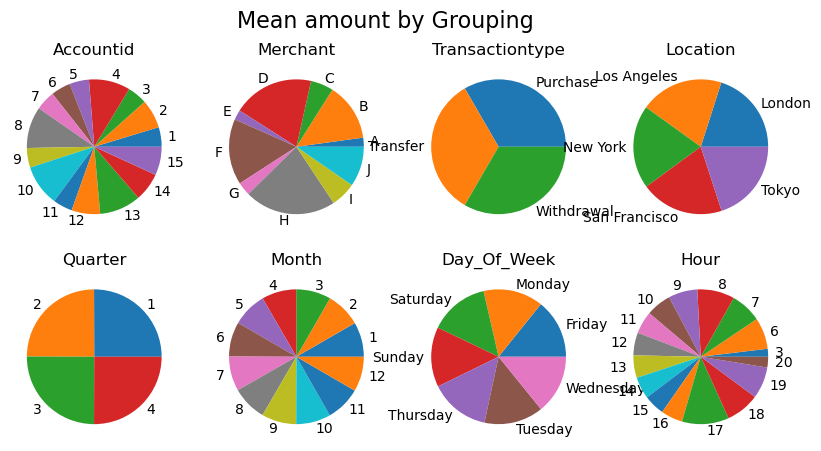

In [8]:
# Mean Amount by grouping
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = engData.groupby(col)['Amount'].mean()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Mean amount by Grouping', fontsize=16)
plt.show()

In [9]:
# Outlier Detection
def find_outliers_zscore(series, threshold=2.5):
    z_scores = zscore(series)
    outliers = series[abs(z_scores) > threshold]
    return outliers


outliers_zscore = find_outliers_zscore(engData['Amount'])
print("\nOutliers using Z-score method (threshold=3):")
print(outliers_zscore.index)


def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers


outliers_iqr = find_outliers_iqr(engData['Amount'])
print("\nOutliers using IQR method:")
print(outliers_iqr.index)

outliers = engData.iloc[outliers_iqr.index]
print(outliers.to_markdown())

# We need to examine these outliers closely.


Outliers using Z-score method (threshold=3):
Index([    43,     79,   1184,   1203,   1260,   1482,   1622,   1683,   1708,
         2189,
       ...
       398644, 398698, 398824, 398924, 398947, 399173, 399246, 399486, 399664,
       399830],
      dtype='int64', length=3009)

Outliers using IQR method:
Index([     2,     43,     79,    638,    736,    786,    809,    978,   1036,
         1140,
       ...
       399486, 399491, 399498, 399603, 399616, 399664, 399703, 399784, 399830,
       399998],
      dtype='int64', length=6927)
|        | Timestamp           |   TransactionID |   AccountID |      Amount | Merchant   | TransactionType   | Location      |   Year |   Quarter |   Month | Day_Of_Week   |   Day_Of_Month |   Day_Of_Year |   Hour |   Minute |
|-------:|:--------------------|----------------:|------------:|------------:|:-----------|:------------------|:--------------|-------:|----------:|--------:|:--------------|---------------:|--------------:|-------:|---------:|
| 

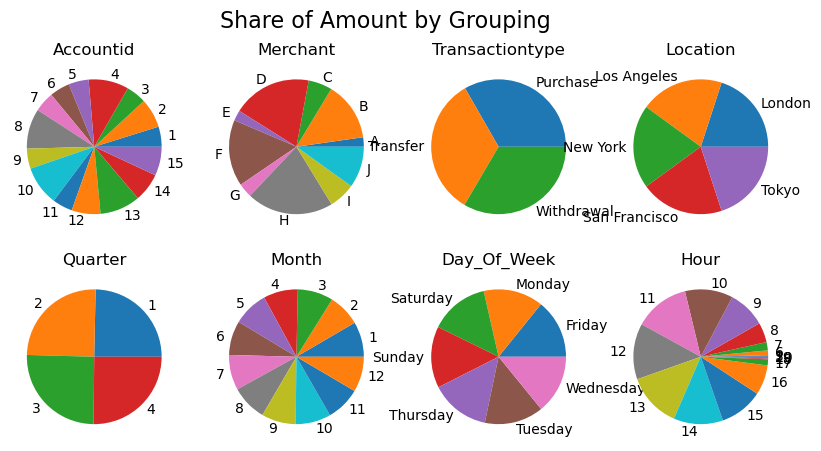

In [10]:
# replot distribution without outliers
sans_outliers = engData.drop(index=outliers.index)

# Check for Amount Sum across categories
fig, axs = plt.subplots(2, 4, figsize=(10, 5)) 
axs = axs.flatten()
for i, col in enumerate(['AccountID', 'Merchant','TransactionType','Location','Quarter','Month','Day_Of_Week', 'Hour']):
    grouped = sans_outliers.groupby(col)['Amount'].sum()
    grouped.plot(kind='pie', ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_title(col.title())

fig.suptitle('Share of Amount by Grouping', fontsize=16)
plt.show()
# Removing the outliers had no significant impact on share of Amount

In [11]:
# How many records have a whole-number for their amount?
whole_number_rows = engData[(engData['Amount'] % 1 == 0)]
print(len(whole_number_rows))
# print(whole_number_rows.to_markdown())

#  Whole Number rows seem to be 1/10th of the data set, this is congruent with Benford's Law findings below... 

15414


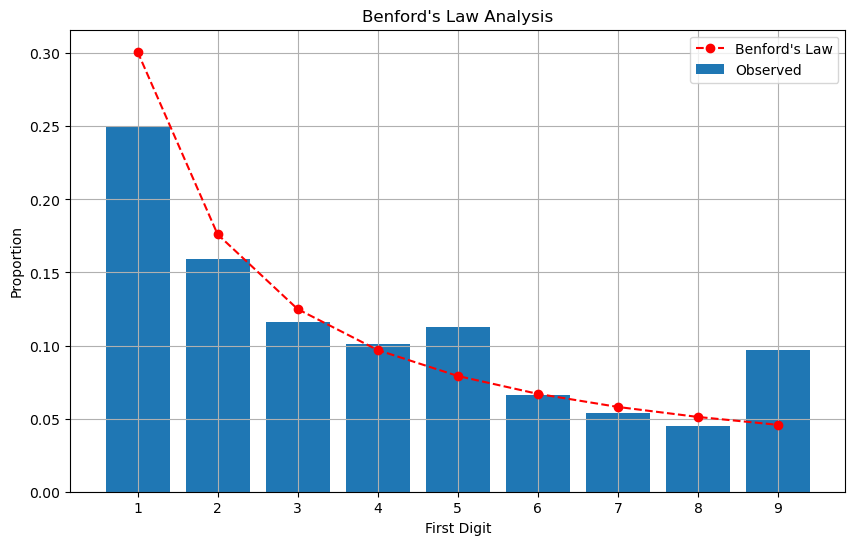

In [12]:
# Check Benford's law for Amount (https://en.wikipedia.org/wiki/Benford%27s_law)
benData = engData.copy()
benData['first_digit'] = benData['Amount'].astype(str).str[0].astype(int)
observed_counts = benData['first_digit'].value_counts().sort_index()
observed_proportions = observed_counts / len(benData)
benford_expected_proportions = pd.Series([np.log10(1 + 1/d) for d in range(1, 10)], index=range(1, 10))

plt.figure(figsize=(10, 6))
plt.bar(observed_proportions.index, observed_proportions.values, label='Observed')
plt.plot(benford_expected_proportions.index, benford_expected_proportions.values, color='red', marker='o', linestyle='--', label='Benford\'s Law')
plt.xlabel('First Digit')
plt.ylabel('Proportion')
plt.title('Benford\'s Law Analysis')
plt.legend()
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()

# According to Benford's Law, these books have been cooked !!!!!
# Graph indicates presence of anomalies or potential data manipulation